<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Currency_Tracker_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

💹 Live Exchange Rates (Base: USD)
----------------------------------------
  1 USD = 0.85 EUR
  1 USD = 0.74 GBP
  1 USD = 3.75 SAR
  1 USD = 39.99 MRU
  1 USD = 3724.68 UGX
  1 USD = 157.09 JPY
  1 USD = 3.67 AED

💰 Converting 100 USD:
----------------------------------------
  100 USD = 85.30 EUR
  100 USD = 73.70 GBP
  100 USD = 375.00 SAR
  100 USD = 3999.00 MRU
  100 USD = 372468.00 UGX
  100 USD = 15709.00 JPY
  100 USD = 367.00 AED


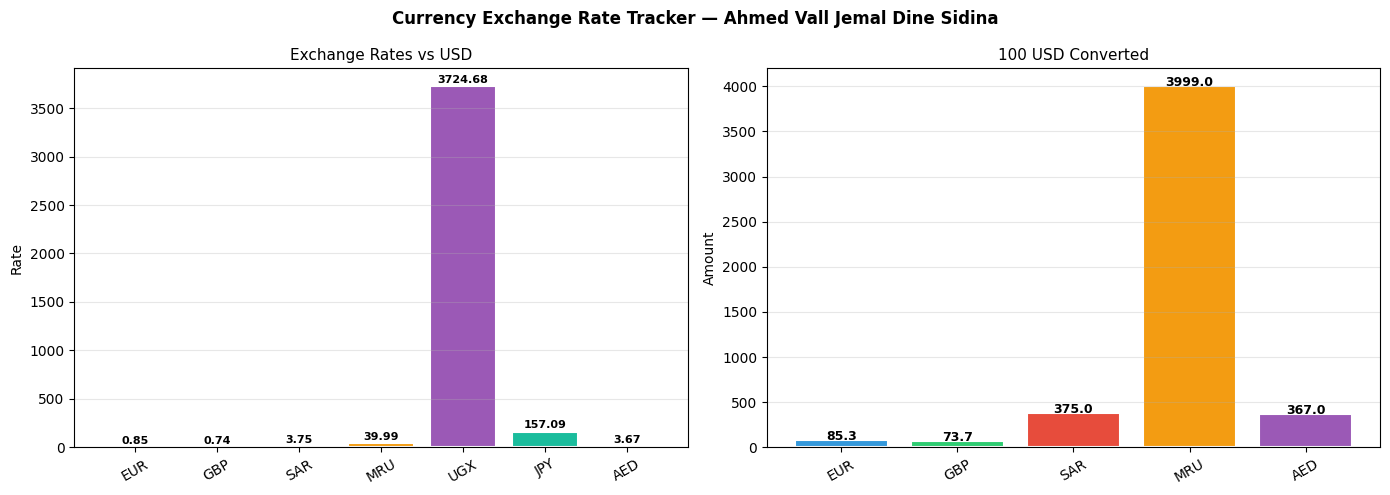

✅ تم حفظ الرسم البياني!


In [1]:
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── جلب أسعار العملات ──
def get_rate(from_curr, to_curr):
    try:
        url = f"https://api.exchangerate-api.com/v4/latest/{from_curr}"
        data = requests.get(url).json()
        return data['rates'][to_curr]
    except:
        return None

# عملات متعددة
base = "USD"
currencies = ["EUR", "GBP", "SAR", "MRU", "UGX", "JPY", "AED"]
rates = {}

print("💹 Live Exchange Rates (Base: USD)")
print("-" * 40)
for curr in currencies:
    rate = get_rate(base, curr)
    if rate:
        rates[curr] = rate
        print(f"  1 USD = {rate:.2f} {curr}")

# تحويل مبلغ
amount = 100
print(f"\n💰 Converting {amount} USD:")
print("-" * 40)
for curr, rate in rates.items():
    print(f"  {amount} USD = {amount * rate:.2f} {curr}")

# ── الرسم البياني ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Currency Exchange Rate Tracker — Ahmed Vall Jemal Dine Sidina',
             fontsize=12, fontweight='bold')

# 1️⃣ أسعار الصرف
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22']
bars = axes[0].bar(list(rates.keys()), list(rates.values()),
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, (curr, rate) in zip(bars, rates.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(rates.values())*0.01,
                 f'{rate:.2f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Exchange Rates vs USD', fontsize=11)
axes[0].set_ylabel('Rate')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=30)

# 2️⃣ تحويل 100 دولار
converted = {curr: amount * rate for curr, rate in rates.items()}
# نستثني UGX و JPY لأنها كبيرة جداً
display = {k: v for k, v in converted.items() if k not in ['UGX', 'JPY']}
bars2 = axes[1].bar(list(display.keys()), list(display.values()),
                     color=colors[:len(display)],
                     edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, display.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title(f'{amount} USD Converted', fontsize=11)
axes[1].set_ylabel('Amount')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('currency_tracker_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ تم حفظ الرسم البياني!")